In [1]:
import pandas as pd
import numpy as np
import requests
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import time

In [2]:
FEE_RATE = 0.001
CAPITAL = 1_000 # $1000 per side, $2000 per trade
FIXED_END = int(pd.Timestamp('2026-07-05').timestamp() * 1000)

In [3]:
def get_historical_data(symbol, interval='60', num_candles=5000, end=FIXED_END):
    if not end:
        end = int(time.time() * 1000)
    
    # docs: https://bybit-exchange.github.io/docs/v5/market/kline
    url = 'https://api.bybit.com/v5/market/kline'
    all_data = []
    end = int(time.time() * 1000)

    while len(all_data) < num_candles:
        params = {
            'category': 'spot',
            'symbol': symbol,
            'interval': interval,
            'limit': 1000,
            'end': end
        }
        r = requests.get(url, params=params)
        data = r.json()['result']['list']
        if not data:
            break
        all_data.extend(data)
        end = int(data[-1][0]) - 1
        time.sleep(0.01)

    df = pd.DataFrame(all_data, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'].astype(float), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[['timestamp', 'close']].sort_values('timestamp').reset_index(drop=True)
    return df.iloc[:num_candles]

def backtest(price_a, price_b, zscore, capital=CAPITAL, fee_rate=FEE_RATE):
    position = 0
    pnl = 0
    pnl_history = []

    for i in range(1, len(zscore)):
        if position == 0 and zscore[i] > 2:
            position = -1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == 0 and zscore[i] < -2:
            position = 1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == -1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (entry_price_a - price_a[i])
            pnl += units_b * (price_b[i] - entry_price_b)
            pnl -= fee_rate * capital * 4
            position = 0
        elif position == 1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (price_a[i] - entry_price_a)
            pnl += units_b * (entry_price_b - price_b[i])
            pnl -= fee_rate * capital * 4
            position = 0

        pnl_history.append(pnl)
    return pnl_history

def analyse_pair(symbol_a, symbol_b, data):
    df_a = data[symbol_a]
    df_b = data[symbol_b]
    price_a = df_a['close'].values
    price_b = df_b['close'].values
    n = min(len(price_a), len(price_b))

    if n < 5000:
        print(f"insufficient data for {symbol_a}|{symbol_b}")
        return 
        
    price_a = price_a[:n]
    price_b = price_b[:n]

    timestamps_train = df_a['timestamp'][:2500]
    price_a_train = price_a[:2500]
    price_b_train = price_b[:2500]
    
    _, pvalue, _ = coint(price_a_train, price_b_train,)
    print(f"cointegration p-value (train): {pvalue:.4f}")

    beta = np.cov(price_a_train, price_b_train)[0, 1] / np.var(price_b_train)
    alpha = np.mean(price_a_train) - beta * np.mean(price_b_train)
    spread_train = price_a_train - alpha - beta * price_b_train

    timestamps_test = df_a['timestamp'][2500:5000]
    price_a_test = price_a[2500:5000]
    price_b_test = price_b[2500:5000]
    spread_test = price_a_test - alpha - beta * price_b_test
    zscore = (spread_test - spread_train.mean()) / spread_train.std()

    pnl_history = backtest(price_a_test, price_b_test, zscore, capital=CAPITAL)
    days = int(len(price_a_test)) // 24
    print(f"total pnl: ${pnl_history[-1]:.2f} over {days} days")
    print(f"daily pnl: ${pnl_history[-1]/days:.2f}/day")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{symbol_a}|{symbol_b}')

    axes[0, 0].plot(timestamps_test, price_a_test / price_a_test[0], label=symbol_a)
    axes[0, 0].plot(timestamps_test, price_b_test / price_b_test[0], label=symbol_b)
    axes[0, 0].set_title('prices')
    axes[0, 0].legend()
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].plot(timestamps_test, spread_test)
    axes[0, 1].set_title('spread')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].plot(timestamps_test, zscore)
    axes[1, 0].axhline(2, color='red', linestyle='--', label='short signal')
    axes[1, 0].axhline(-2, color='green', linestyle='--', label='long signal')
    axes[1, 0].axhline(0, color='gray', linestyle=':')
    axes[1, 0].set_title('z-score')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].plot(timestamps_test[1:], pnl_history)
    axes[1, 1].axhline(0, color='gray', linestyle=':')
    axes[1, 1].set_title('cumulative pnl')
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

In [4]:
# docs: https://bybit-exchange.github.io/docs/v5/market/tickers
url = 'https://api.bybit.com/v5/market/tickers'
params = {'category': 'spot'}
r = requests.get(url, params=params)
tickers = [ticker['symbol'] for ticker in r.json()['result']['list']]
print(len(tickers))
print(tickers[:50])

598
['USATUSDT', 'RLUSDUSDT', 'TRXUSDT', 'TOSHIUSDT', 'VOOIUSDT', 'BELUSDT', 'RPLUSDT', 'BATUSDT', 'DOGSUSDT', 'XUSDUSDT', 'BREVUSDT', 'HYPERUSDT', 'WUSDT', 'GPSUSDT', 'AVAXUSDT', 'FETUSDT', 'ENSUSDT', 'CBKUSDT', 'STREAMUSDT', 'INTERUSDT', 'BNBUSDT', 'ZETAUSDT', 'NEIROCTOUSDT', 'VIRTUALUSDT', 'ZROUSDT', 'PYTHUSDC', 'ICPUSDT', 'GLMRUSDT', 'DOGEMNT', 'ROAMUSDT', 'ERAUSDT', 'STETHUSDT', 'WBTCBTC', 'LAUSDT', 'MCRTUSDT', 'NXPCMNT', 'USDCBRL', 'RATSUSDT', 'ETHBRL', 'PUMPMNT', 'ANIMEUSDT', 'SOLBRL', 'ENJUSDT', 'USDYUSDT', 'GODSUSDT', 'XDCUSDT', 'SIGNUSDT', 'SUIUSDT', 'ZKPUSDT', 'ETHRLUSD']


In [5]:
btc = get_historical_data('BTCUSDT', end=FIXED_END)
eth = get_historical_data('ETHUSDT', end=FIXED_END)
sol = get_historical_data('SOLUSDT', end=FIXED_END)
btc.head()

,timestamp,close
0,2025-12-09 09:00:00,90134.2
1,2025-12-09 10:00:00,90297.7
2,2025-12-09 11:00:00,90388.3
3,2025-12-09 12:00:00,90572.3
4,2025-12-09 13:00:00,90419.9


In [6]:
data = {
    'BTC': btc,
    'ETH': eth,
    'SOL': sol,
}
major = ['BTC', 'ETH', 'SOL']

for i, a in enumerate(major):
    for j, b in enumerate(major):
        if j > i:
            _, pvalue, _ = coint(data[a]['close'], data[b]['close'])
            print(f"{a}|{b}: {pvalue:.4f}")

BTC|ETH: 0.4101
BTC|SOL: 0.9028
ETH|SOL: 0.7356


In [7]:
tickers_usdt = [t for t in tickers if t.endswith('USDT')]
print(len(tickers_usdt))
print(tickers_usdt[:50])

431
['USATUSDT', 'RLUSDUSDT', 'TRXUSDT', 'TOSHIUSDT', 'VOOIUSDT', 'BELUSDT', 'RPLUSDT', 'BATUSDT', 'DOGSUSDT', 'XUSDUSDT', 'BREVUSDT', 'HYPERUSDT', 'WUSDT', 'GPSUSDT', 'AVAXUSDT', 'FETUSDT', 'ENSUSDT', 'CBKUSDT', 'STREAMUSDT', 'INTERUSDT', 'BNBUSDT', 'ZETAUSDT', 'NEIROCTOUSDT', 'VIRTUALUSDT', 'ZROUSDT', 'ICPUSDT', 'GLMRUSDT', 'ROAMUSDT', 'ERAUSDT', 'STETHUSDT', 'LAUSDT', 'MCRTUSDT', 'RATSUSDT', 'ANIMEUSDT', 'ENJUSDT', 'USDYUSDT', 'GODSUSDT', 'XDCUSDT', 'SIGNUSDT', 'SUIUSDT', 'ZKPUSDT', 'SKRUSDT', 'WALUSDT', 'ZEREBROUSDT', 'DYMUSDT', 'ROSEUSDT', 'SSVUSDT', 'HFTUSDT', 'FTTUSDT', 'FLRUSDT']


In [8]:
# inspect ticker fields, turnover24h used for liquidity filter
print(r.json()['result']['list'][0])

{'symbol': 'USATUSDT', 'bid1Price': '0.9997', 'bid1Size': '160', 'ask1Price': '0.9999', 'ask1Size': '32.5', 'lastPrice': '0.9998', 'prevPrice24h': '0.9998', 'price24hPcnt': '0', 'highPrice24h': '1', 'lowPrice24h': '0.9992', 'turnover24h': '26002.503057', 'volume24h': '26005.87', 'usdIndexPrice': '0.998938'}


In [9]:
tickers_filt = [t_info['symbol'] for t_info in r.json()['result']['list']
                if float(t_info['turnover24h']) > 1_000_000
                and t_info['symbol'].endswith('USDT')]
print(len(tickers_filt))
print(tickers_filt[:50])

57
['TRXUSDT', 'AVAXUSDT', 'BNBUSDT', 'SUIUSDT', 'USDEUSDT', 'AEROUSDT', 'HYPEUSDT', 'PUMPUSDT', 'PENGUUSDT', 'DOTUSDT', 'ADAUSDT', 'MONUSDT', 'GRAMUSDT', 'BSBUSDT', 'LITUSDT', 'BTCUSDT', 'SOLUSDT', 'NEARUSDT', 'WIFUSDT', 'GRASSUSDT', 'ENAUSDT', 'WLDUSDT', 'ONDOUSDT', 'BCHUSDT', 'SHIBUSDT', 'XPLUSDT', 'HBARUSDT', 'NIGHTUSDT', 'VANRYUSDT', 'XLMUSDT', 'PEPEUSDT', 'HMSTRUSDT', 'USDCUSDT', 'CAPUSDT', 'ARXUSDT', 'HUSDT', 'CCUSDT', 'TAIKOUSDT', 'LINKUSDT', 'BONKUSDT', 'XAUTUSDT', 'STRKUSDT', 'UNIUSDT', 'ETHUSDT', 'SPXUSDT', 'XRPUSDT', 'USD1USDT', 'VVVUSDT', 'ETHFIUSDT', 'LTCUSDT']


In [10]:
data_filt = {}
for ticker in tickers_filt:
    data_filt[ticker] = get_historical_data(ticker, end=FIXED_END)

results = []
for i, a in enumerate(tickers_filt):
    for j, b in enumerate(tickers_filt):
        if j > i:
            n = min(len(data_filt[a]), len(data_filt[b]))
            _, pvalue, _ = coint(data_filt[a]['close'].iloc[:n], data_filt[b]['close'].iloc[:n])
            results.append([a, b, pvalue])

results_df = pd.DataFrame(results, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_df[results_df['pvalue'] < 0.01].sort_values('pvalue')
print(strong.head(20))

       ticker_a   ticker_b        pvalue
1413  TAIKOUSDT    XRPUSDT  6.507906e-12
1424  TAIKOUSDT   AAVEUSDT  9.005743e-12
1418  TAIKOUSDT  TRUMPUSDT  9.136290e-12
1417  TAIKOUSDT    LTCUSDT  4.408535e-11
1411  TAIKOUSDT    ETHUSDT  6.358693e-11
1407  TAIKOUSDT   BONKUSDT  1.969685e-10
1416  TAIKOUSDT  ETHFIUSDT  3.874402e-10
1406  TAIKOUSDT   LINKUSDT  4.931888e-10
1410  TAIKOUSDT    UNIUSDT  2.855995e-09
1409  TAIKOUSDT   STRKUSDT  3.376921e-09
1420  TAIKOUSDT    MNTUSDT  4.395519e-08
1423  TAIKOUSDT   DOGEUSDT  7.291977e-08
541     ADAUSDT  TAIKOUSDT  3.782493e-07
1198  VANRYUSDT  TAIKOUSDT  7.531025e-07
796     SOLUSDT  TAIKOUSDT  1.024566e-06
1131   HBARUSDT  NIGHTUSDT  1.433731e-06
495     DOTUSDT  TAIKOUSDT  9.259032e-06
1415  TAIKOUSDT    VVVUSDT  1.080040e-05
91     AVAXUSDT  TAIKOUSDT  1.155685e-05
225    USDEUSDT   GRAMUSDT  1.209755e-05


In [11]:
print(len(strong))
print(strong.to_string())

111
       ticker_a   ticker_b        pvalue
1413  TAIKOUSDT    XRPUSDT  6.507906e-12
1424  TAIKOUSDT   AAVEUSDT  9.005743e-12
1418  TAIKOUSDT  TRUMPUSDT  9.136290e-12
1417  TAIKOUSDT    LTCUSDT  4.408535e-11
1411  TAIKOUSDT    ETHUSDT  6.358693e-11
1407  TAIKOUSDT   BONKUSDT  1.969685e-10
1416  TAIKOUSDT  ETHFIUSDT  3.874402e-10
1406  TAIKOUSDT   LINKUSDT  4.931888e-10
1410  TAIKOUSDT    UNIUSDT  2.855995e-09
1409  TAIKOUSDT   STRKUSDT  3.376921e-09
1420  TAIKOUSDT    MNTUSDT  4.395519e-08
1423  TAIKOUSDT   DOGEUSDT  7.291977e-08
541     ADAUSDT  TAIKOUSDT  3.782493e-07
1198  VANRYUSDT  TAIKOUSDT  7.531025e-07
796     SOLUSDT  TAIKOUSDT  1.024566e-06
1131   HBARUSDT  NIGHTUSDT  1.433731e-06
495     DOTUSDT  TAIKOUSDT  9.259032e-06
1415  TAIKOUSDT    VVVUSDT  1.080040e-05
91     AVAXUSDT  TAIKOUSDT  1.155685e-05
225    USDEUSDT   GRAMUSDT  1.209755e-05
873     WIFUSDT  TAIKOUSDT  1.808584e-05
1080   SHIBUSDT  TAIKOUSDT  1.958269e-05
1141   HBARUSDT  TAIKOUSDT  3.243780e-05
145     BNBU

In [12]:
tickers_liquid = [t_info['symbol'] for t_info in r.json()['result']['list']
               if float(t_info['turnover24h']) > 5_000_000
               and t_info['symbol'].endswith('USDT')]
print(len(tickers_liquid))
print(tickers_liquid)

15
['HYPEUSDT', 'ADAUSDT', 'LITUSDT', 'BTCUSDT', 'SOLUSDT', 'XPLUSDT', 'USDCUSDT', 'CAPUSDT', 'ARXUSDT', 'ETHUSDT', 'XRPUSDT', 'TRUMPUSDT', 'MNTUSDT', 'SLXUSDT', 'DOGEUSDT']


In [13]:
data_liquid = {}
for ticker in tickers_liquid:
    data_liquid[ticker] = get_historical_data(ticker, end=FIXED_END)

results_liquid = []
for i, a in enumerate(tickers_liquid):
    for j, b in enumerate(tickers_liquid):
        if j > i:
            n = min(len(data_liquid[a]), len(data_liquid[b]))
            _, pvalue, _ = coint(data_liquid[a]['close'].iloc[:n], data_liquid[b]['close'].iloc[:n])
            results_liquid.append([a, b, pvalue])

results_liquid_df = pd.DataFrame(results_liquid, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_liquid_df[results_liquid_df['pvalue'] < 0.05]
strong_filt = strong[(strong['ticker_a'] != 'USDCUSDT') & (strong['ticker_b'] != 'USDCUSDT')] # USDCUSDT is a stablecoin pegged to US dollar (spread reduces to mean reversion)
print(len(strong_filt))
print(strong_filt.to_string())

8
   ticker_a  ticker_b    pvalue
20  ADAUSDT   ARXUSDT  0.045817
37  LITUSDT   SLXUSDT  0.031344
53  SOLUSDT   ARXUSDT  0.027914
78  CAPUSDT   ETHUSDT  0.028278
79  CAPUSDT   XRPUSDT  0.046786
82  CAPUSDT   SLXUSDT  0.014375
83  CAPUSDT  DOGEUSDT  0.047048
90  ETHUSDT   XRPUSDT  0.042098


ADAUSDT|ARXUSDT
insufficient data for ADAUSDT|ARXUSDT
LITUSDT|SLXUSDT
insufficient data for LITUSDT|SLXUSDT
SOLUSDT|ARXUSDT
insufficient data for SOLUSDT|ARXUSDT
CAPUSDT|ETHUSDT
insufficient data for CAPUSDT|ETHUSDT
CAPUSDT|XRPUSDT
insufficient data for CAPUSDT|XRPUSDT
CAPUSDT|SLXUSDT
insufficient data for CAPUSDT|SLXUSDT
CAPUSDT|DOGEUSDT
insufficient data for CAPUSDT|DOGEUSDT
ETHUSDT|XRPUSDT
cointegration p-value (train): 0.0097
total pnl: $63.27 over 104 days
daily pnl: $0.61/day


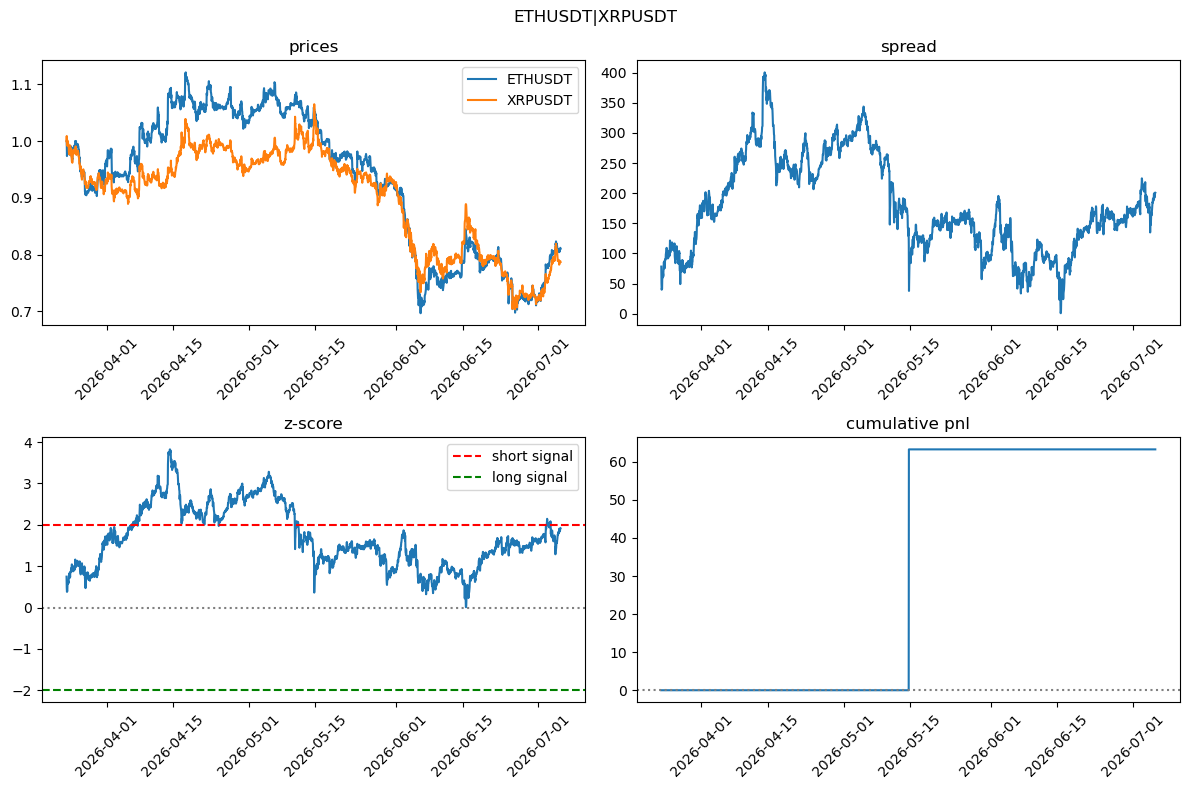

In [14]:
for ticker_a, ticker_b in zip(strong_filt['ticker_a'], strong_filt['ticker_b']):
    print(f"{ticker_a}|{ticker_b}")
    analyse_pair(ticker_a, ticker_b, data_liquid)